<a href="https://colab.research.google.com/github/AndrijaM06/car-price-prediction/blob/main/06_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluacija i poređenje regresionih modela (Google Colab verzija)

Učitavamo sva četiri istrenirana modela, pravimo predikcije nad istim test
skupom i računamo metrike (MAE, MSE, RMSE, R²) kako bismo pošteno uporedili
rezultate i izabrali finalni model.

## Preuzimanje potrebnih fajlova sa GitHub-a

Preuzimamo skript za pretprocesiranje, skup podataka i sva 4 istrenirana
modela direktno sa GitHub-a, bez kloniranja celog repozitorijuma.

In [4]:
import os
import urllib.request

os.makedirs("src", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

base_url = "https://raw.githubusercontent.com/AndrijaM06/car-price-prediction/main"

files_to_download = {
    "src/data_preprocessing.py": f"{base_url}/src/data_preprocessing.py",
    "data/cars_features.csv": f"{base_url}/data/cars_features.csv",
    "models/linear_regression_model.joblib": f"{base_url}/models/linear_regression_model.joblib",
    "models/decision_tree_model.joblib": f"{base_url}/models/decision_tree_model.joblib",
    "models/svm_model.joblib": f"{base_url}/models/svm_model.joblib",
}

for local_path, url in files_to_download.items():
    urllib.request.urlretrieve(url, local_path)
    print(f"Preuzeto: {local_path}")

Preuzeto: src/data_preprocessing.py
Preuzeto: data/cars_features.csv
Preuzeto: models/linear_regression_model.joblib
Preuzeto: models/decision_tree_model.joblib
Preuzeto: models/svm_model.joblib


## Učitavanje podataka i pravljenje iste podele kao pri treniranju

In [5]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from src.data_preprocessing import split_features_and_target

DATA_PATH = Path("data/cars_features.csv")
df = pd.read_csv(DATA_PATH)

X, y = split_features_and_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

print("Test set shape:", X_test.shape)

Test set shape: (11117, 15)


## Učitavanje sva četiri istrenirana modela

In [6]:
import joblib

MODELS_DIR = Path("models")

model_files = {
    "Linear Regression": "linear_regression_model.joblib",
    "Decision Tree": "decision_tree_model.joblib",
    "SVM": "svm_model.joblib",
}

loaded_models = {
    name: joblib.load(MODELS_DIR / filename)
    for name, filename in model_files.items()
}

list(loaded_models.keys())

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid

['Linear Regression', 'Decision Tree', 'SVM']

## Računanje metrika za svaki model

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
predictions_by_model = {}

for model_name, model in loaded_models.items():
    y_pred = model.predict(X_test)
    predictions_by_model[model_name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({"model": model_name, "mae": mae, "mse": mse, "rmse": rmse, "r2": r2})

results_df = pd.DataFrame(results).sort_values(by="mae").reset_index(drop=True)
results_df

,model,mae,mse,rmse,r2
0,Decision Tree,1518.473944,1.965644e+07,4433.558549,0.749216
1,Linear Regression,2519.969254,2.802964e+07,5294.302420,0.642387
2,SVM,3332.140049,6.353635e+07,7970.969281,0.189379


## Tumačenje rezultata

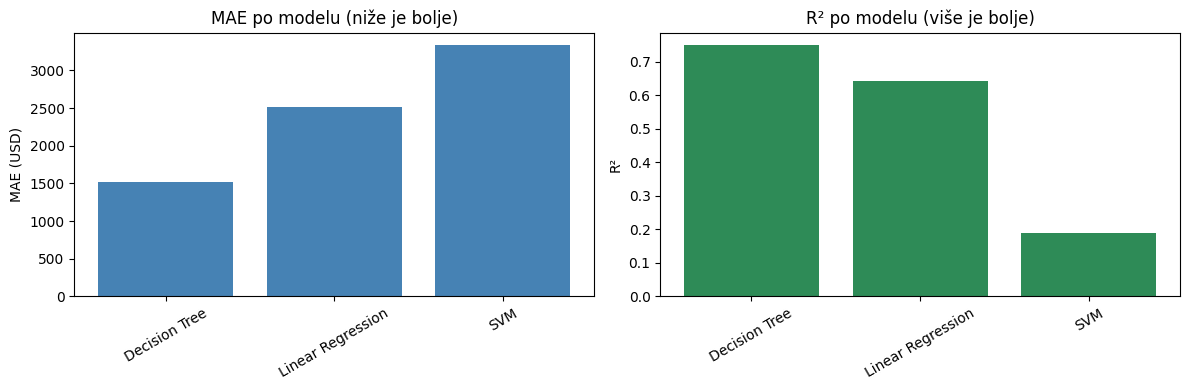

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results_df["model"], results_df["mae"], color="steelblue")
axes[0].set_title("MAE po modelu (niže je bolje)")
axes[0].set_ylabel("MAE (USD)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(results_df["model"], results_df["r2"], color="seagreen")
axes[1].set_title("R² po modelu (više je bolje)")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Detaljna analiza najboljeg modela

In [9]:
best_model_name = results_df.iloc[0]["model"]
print("Najbolji model:", best_model_name)

best_predictions = predictions_by_model[best_model_name]

prediction_analysis = pd.DataFrame({
    "actual_price_usd": y_test.values,
    "predicted_price_usd": best_predictions,
})
prediction_analysis["error_usd"] = (
    prediction_analysis["actual_price_usd"] - prediction_analysis["predicted_price_usd"]
)
prediction_analysis["absolute_error_usd"] = prediction_analysis["error_usd"].abs()

prediction_analysis.sample(10, random_state=42)

Najbolji model: Decision Tree


,actual_price_usd,predicted_price_usd,error_usd,absolute_error_usd
1864,21800,24000.0,-2200.0,2200.0
3352,5500,6500.0,-1000.0,1000.0
5094,25500,19900.0,5600.0,5600.0
8685,4950,5000.0,-50.0,50.0
7539,40000,39500.0,500.0,500.0
3011,9800,2500.0,7300.0,7300.0
1662,4450,3600.0,850.0,850.0
4256,4200,3000.0,1200.0,1200.0
321,350,500.0,-150.0,150.0
673,18600,20350.0,-1750.0,1750.0


## Primeri sa najvećom greškom

In [10]:
prediction_analysis.sort_values("absolute_error_usd", ascending=False).head(10)

,actual_price_usd,predicted_price_usd,error_usd,absolute_error_usd
3083,195000,25900.0,169100.0,169100.0
6931,170477,25900.0,144577.0,144577.0
3099,183848,45555.0,138293.0,138293.0
9812,235235,98500.0,136735.0,136735.0
402,190141,60550.0,129591.0,129591.0
2590,120000,19700.0,100300.0,100300.0
9524,74500,9000.0,65500.0,65500.0
6648,116938,57100.0,59838.0,59838.0
9058,88900,32000.0,56900.0,56900.0
4482,99000,42500.0,56500.0,56500.0


**Zaključak:** Najveće greške modela su kod veoma skupih automobila
(preko 100.000$) - takvih ima najmanje u podacima, pa model nema dovoljno
primera da nauči obrazac za taj segment.

## Vizuelizacija: stvarne vs. predviđene cene

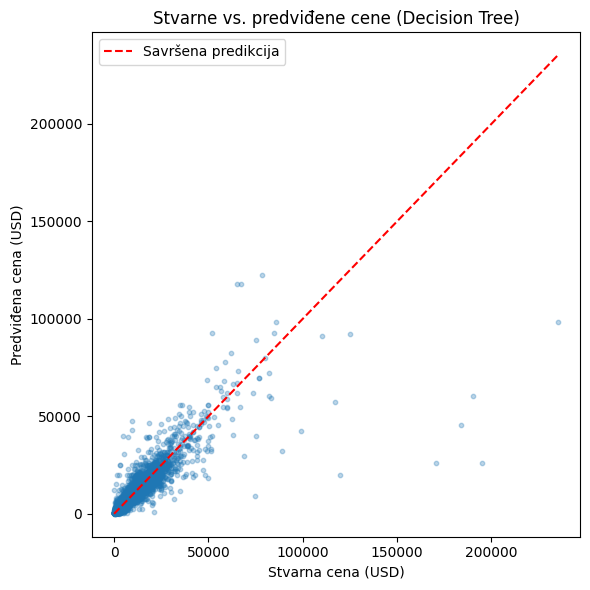

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(prediction_analysis["actual_price_usd"], prediction_analysis["predicted_price_usd"], alpha=0.3, s=10)
max_val = prediction_analysis["actual_price_usd"].max()
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Savršena predikcija")
plt.xlabel("Stvarna cena (USD)")
plt.ylabel("Predviđena cena (USD)")
plt.title(f"Stvarne vs. predviđene cene ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.show()

## Čuvanje finalnog modela

Biramo najbolji model (na osnovu MAE) kao finalni model projekta.

In [12]:
best_model = loaded_models[best_model_name]
FINAL_MODEL_PATH = MODELS_DIR / "car_price_model.joblib"
joblib.dump(best_model, FINAL_MODEL_PATH)

results_df.to_csv(MODELS_DIR / "model_comparison_results.csv", index=False)

print(f"Finalni model ({best_model_name}) sačuvan u: {FINAL_MODEL_PATH}")

Finalni model (Decision Tree) sačuvan u: models/car_price_model.joblib


## Preuzimanje finalnog modela i tabele rezultata na svoj računar

In [13]:
from google.colab import files

files.download(str(FINAL_MODEL_PATH))
files.download(str(MODELS_DIR / "model_comparison_results.csv"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>